# Unestructured linear search 

In [22]:
import time
import random

In [23]:
# Simulates an unstructured (linear) search over 2^n items.
# Returns the number of queries needed to find the target.
def classical_search(target, n_qubits):
    N = 2 ** n_qubits
    items = list(range(N))
    random.shuffle(items)       # Unstructured: random order
    
    queries = 0
    for item in items:
        queries += 1
        if item == target:
            return queries
    return queries

# Generalized Grover to n qubits

In [24]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
import numpy as np

In [ ]:
# Oracle that marks the target state by flipping its phase.
# Uses a multi-controlled Z gate.
def grover_oracle(n_qubits, target):
    qc = QuantumCircuit(n_qubits, name='oracle')
    
    # Flip qubits where target bit is 0 (so all-ones = target)
    target_bits = format(target, f'0{n_qubits}b')       # format(5, '03b') = "101"
    for i, bit in enumerate(reversed(target_bits)):     # reversed becuase the qubit 0 is the less significant
        if bit == '0':
            qc.x(i)
    
    # Multi-controlled Z
    qc.h(n_qubits - 1)
    qc.mcx(list(range(n_qubits - 1)), n_qubits - 1)     # Generalized Toffoli
    qc.h(n_qubits - 1)
    
    # Undo the flips
    for i, bit in enumerate(reversed(target_bits)):
        if bit == '0':
            qc.x(i)
    
    return qc

In [26]:
# Grover diffusion operator (reflection about the mean).
def grover_reflection(n_qubits):
    qc = QuantumCircuit(n_qubits, name='reflection')
    qc.h(range(n_qubits))
    qc.x(range(n_qubits))
    qc.h(n_qubits - 1)
    qc.mcx(list(range(n_qubits - 1)), n_qubits - 1)
    qc.h(n_qubits - 1)
    qc.x(range(n_qubits))
    qc.h(range(n_qubits))
    return qc

In [27]:
# Full Grover circuit for n_qubits searching for target.
# Returns the most measured state and its probability.
def grover_search(n_qubits, target, shots=1000):
    N = 2 ** n_qubits

    # Optimal number of iterations: π/4 * √N
    n_iterations = int(np.pi / 4 * np.sqrt(N))
    
    oracle = grover_oracle(n_qubits, target)
    reflection = grover_reflection(n_qubits)
    
    # Build circuit
    qc = QuantumCircuit(n_qubits, n_qubits)
    qc.h(range(n_qubits))                       # Initial superposition
    
    for _ in range(n_iterations):
        qc.append(oracle, range(n_qubits))
        qc.append(reflection, range(n_qubits))
    
    qc.measure(range(n_qubits), range(n_qubits))
    
    # Run
    backend = AerSimulator()
    transpiled = transpile(qc, backend)
    job = backend.run(transpiled, shots=shots)
    counts = job.result().get_counts()
    
    # Most frequent result
    target_str = format(target, f'0{n_qubits}b')
    target_prob = counts.get(target_str, 0) / shots
    
    return n_iterations, target_prob

# Comparation and Visualization

In [28]:
import matplotlib.pyplot as plt

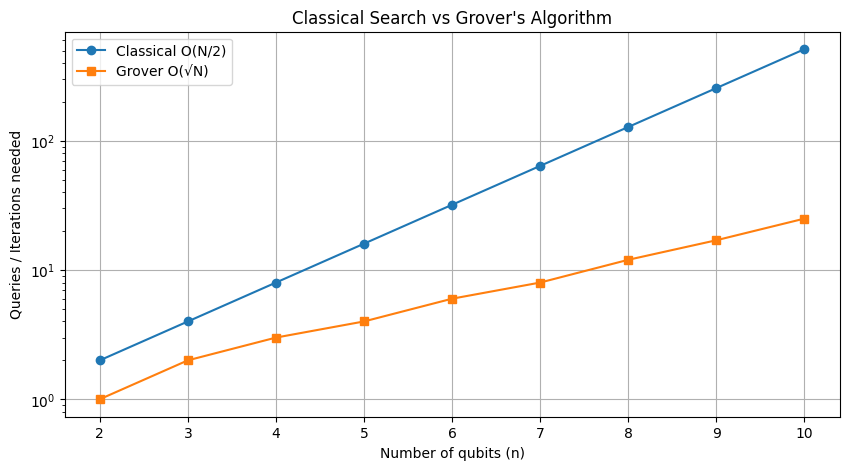

In [29]:
qubit_range = range(2, 11)  # From 2 to 10 qubits
classical_queries = []
grover_iterations = []

target = 0                  # We always search for state |0...0⟩ for simplicity

for n in qubit_range:
    N = 2 ** n
    
    # Classical: average case is N/2 queries
    classical_queries.append(N / 2)
    
    # Grover: π/4 * √N iterations
    grover_iterations.append(int(np.pi / 4 * np.sqrt(N)))

plt.figure(figsize=(10, 5))
plt.plot(list(qubit_range), classical_queries, 'o-', label='Classical O(N/2)')
plt.plot(list(qubit_range), grover_iterations, 's-', label='Grover O(√N)')
plt.xlabel('Number of qubits (n)')
plt.ylabel('Queries / Iterations needed')
plt.title('Classical Search vs Grover\'s Algorithm')
plt.legend()
plt.yscale('log')
plt.grid(True)
plt.show()